# Data Mining Assignment 6 - Izaak King, kingi@rpi.edu
Attached is my submission for assignment 6.

## Data preparation

We first parse our given Breast Cancer Wisconsin (Diagnostic) dataset into a data matrix. ID variable isn't used, and Diagnosis variable will be used as class labels for the classification task. The remaining data matrix, 569 x 30 will be scaled with sklearn's MinMaxScalar.

We code the malign class as +1 and and the benign class as -1. Then, we augment our dataset by adding a column of ones. Finally, we use klearn.train_test_split, with a random_state of 42, and shuffle = True to create test data of size 100, validation data of size 69, and training data of size 400. 

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

rawData = pd.read_csv("wdbc.data", header=None)          # Use Pandas Library to parse inital data file, store in Data frame
diagnosisData = (rawData.iloc[ : , 1]).to_numpy()          #The Second column is the Diagosis Variable
dataMatrix = (rawData.iloc[ : , 2: ]).to_numpy()           # Columns 3-32 are saved and added created into a Data Matrix using NumPy. Column 1, Patient ID, is disregarded.
scaler = MinMaxScaler(feature_range=(0, 1))                # Use sklearn's MinMaxScaler
scaledDataMatrix = scaler.fit_transform(dataMatrix)

labels = np.where(diagnosisData == 'M', 1, -1)        # Encode labels with M = 1, B = -1

ones_column = np.ones((scaledDataMatrix.shape[0], 1))     # Add a column of ones to our matrix
augmentedDataMatrix = np.hstack((scaledDataMatrix, ones_column))

X_rem, X_test, y_rem, y_test = train_test_split(    # Split the data for test set of 100
    augmentedDataMatrix, labels,
    test_size=100, random_state=42, shuffle=True
) 

X_train, X_val, y_train, y_val = train_test_split(   # Split the data for validation set of 69
    X_rem, y_rem,
    test_size=69, random_state=42, shuffle=True
)

## Dual SVM Algorithm

Now, we implemenent the Dual SVM Algorithm using hinge loss, as found in Algorithm 21.1 in Chapter 21, page 540. The algorithm takes in the data matrix D, our array of labels y, a kernal matrix K, the regularization parameter C, and finally epsilon, the convergence tolerance for stopping. The SVM Algorithm is used to find the optimal dual variables, alpha, that maximize the dual objective function.



In [9]:
def svm_dual(D, y, K, C, epsilon):
    ''' Dual SVM Algorithm using hinge loss. 
    Inputs:
        D = data matrix 
        y = labels (+1 / -1)
        K = kernel matrix 
        C = regularization parameter
        epsilon = convergence tolerance
    '''
    n = D.shape[0]
    alpha = np.zeros(n)
    nk = 1 / np.diag(K)  # Set step size
    alpha_prev = np.copy(alpha)

    max_iters = 100000   # Set max iterations to prevent endless looop

    for t in range(max_iters):
        for k in range(n):
            sum_term = np.sum(alpha * y * K[:, k])   # Compute gradientterm
            alpha[k] += nk[k] * (1 - y[k] * sum_term)   # Dual variable update

            if alpha[k] < 0:
                alpha[k] = 0
            
            elif alpha[k] > C:
                alpha[k] = C

        if np.linalg.norm(alpha - alpha_prev) <= epsilon:    # Check for convergence
            break
        
        alpha_prev = np.copy(alpha)

    return alpha


## Kernel Implementation

With our Dual SVM algorithm implemented, we now implement two kernels, both linear and Gaussian. We wil perform analysis using both of these kernels, experimenting with different values of C, and Sigma^2, to see which combinations give the best accuracy on our validation set. 

A helper function predict is also implemented, which calculates test accuracy of a kernel, defined as the number of correct predictions over the number of points in the given dataset.

In [6]:
def linear_kernel(X1, X2):
    ''' Compute Linear kernel matrix between two datasets X1 and X2. 
    Inputs:
        X1 : ndarray
        X2 : ndarray
    '''
    return X1 @ X2.T

def gaussian_kernel(X1, X2, sigma2):
    '''
    Compute Gaussian kernel matrix between two datasets X1 and X2.
    Inputs:
        X1 : ndarray
        X2 : ndarray
        sigma2 : Spread parameter (sigma^2)
    '''
    X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)    # Compute squared Euclidean distances
    X2_sq = np.sum(X2**2, axis=1).reshape(1, -1)
    numer = X1_sq + X2_sq - 2 * (X1 @ X2.T)

    K = np.exp(-numer / (2 * sigma2))     # Compute Gaussian kernel
    return K

def predict(alpha, y_train, K_test):
    # Helper function to predict labels for a test given trained dual variables alpha
    y_pred = np.sign(K_test @ (alpha * y_train))
    return y_pred


## Selecting Best Parameters, Reporting Test Accuracy

Now, we take C values of 0.001, 0.01, 0.1, 1, 10, 100 and sigma^2 values of 0.001, 0.01, 0.1, 0.5, 1, 5. With these defined values we evaluate the performance of the Linear kernel across the C values, and the performance of the Guassian kernel across combinations of the C values and sigma^2 values. The best performing values for the parameter(s) will be outputted for each kernel, along with that kernel's accuracy along both the validation set, as well as the test set.

In [7]:
# Candidate C, sigma2 values
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
sigma2_values = [0.001, 0.01, 0.1, 0.5, 1, 5]
epsilon = 1e-6

# First using Linear Kernel
best_C_linear = None
best_acc_linear = 0

for C in C_values:
    K_train = linear_kernel(X_train, X_train)
    alpha = svm_dual(X_train, y_train, K_train, C, epsilon)
    
    K_val = linear_kernel(X_val, X_train)   # Validation kernel
    y_val_pred = predict(alpha, y_train, K_val)
    acc = np.mean(y_val_pred == y_val)
    if acc > best_acc_linear:
        best_acc_linear = acc
        best_C_linear = C

print(f"Best Linear Kernel: C = {best_C_linear}\nValidation Accuracy = {best_acc_linear:.4f}")

# Get accuracy for linear kernel using test data
K_test_linear = linear_kernel(X_test, X_train)
alpha_linear = svm_dual(X_train, y_train, linear_kernel(X_train, X_train), best_C_linear, epsilon)
y_test_pred_linear = predict(alpha_linear, y_train, K_test_linear)
test_acc_linear = np.mean(y_test_pred_linear == y_test)
print(f"Linear Kernel Test Accuracy = {test_acc_linear:.4f}")


# Now using Gaussian kernel
best_C_gauss = None
best_sigma2 = None
best_acc_gauss = 0

for C in C_values:
    for sigma2 in sigma2_values:
        K_train = gaussian_kernel(X_train, X_train, sigma2)
        alpha = svm_dual(X_train, y_train, K_train, C, epsilon)
        
        K_val = gaussian_kernel(X_val, X_train, sigma2)
        y_val_pred = predict(alpha, y_train, K_val)
        acc = np.mean(y_val_pred == y_val)
        
        if acc > best_acc_gauss:
            best_acc_gauss = acc
            best_C_gauss = C
            best_sigma2 = sigma2

print(f"Best Gaussian Kernel: C = {best_C_gauss}, sigma2 = {best_sigma2}, Validation Accuracy = {best_acc_gauss:.4f}")

# Get accuracy for Gaussian kernel using test data
K_train_gauss = gaussian_kernel(X_train, X_train, best_sigma2)
alpha_gauss = svm_dual(X_train, y_train, K_train_gauss, best_C_gauss, epsilon)
K_test_gauss = gaussian_kernel(X_test, X_train, best_sigma2)
y_test_pred_gauss = predict(alpha_gauss, y_train, K_test_gauss)
test_acc_gauss = np.mean(y_test_pred_gauss == y_test)
print(f"Gaussian Kernel Test Accuracy = {test_acc_gauss:.4f}")


Best Linear Kernel: C = 1
Validation Accuracy = 0.9855
Linear Kernel Test Accuracy = 0.9800
Best Gaussian Kernel: C = 10, sigma2 = 0.1, Validation Accuracy = 1.0000
Gaussian Kernel Test Accuracy = 0.9600


## PLotting Test Data

Based on the previous results, we find that the best performing linear kernel, with test accuracy of 98% had C = 1. The best performing Gauss kernel, with 96% test accuracy had C = 10 and sigma^2 = 0.1.

Now we will project the test data onto 2D using PCA for dimension reduction. With the 2D projections, we plot our predictions for the test data, with red for malign, green for benign and blue for incorrect.

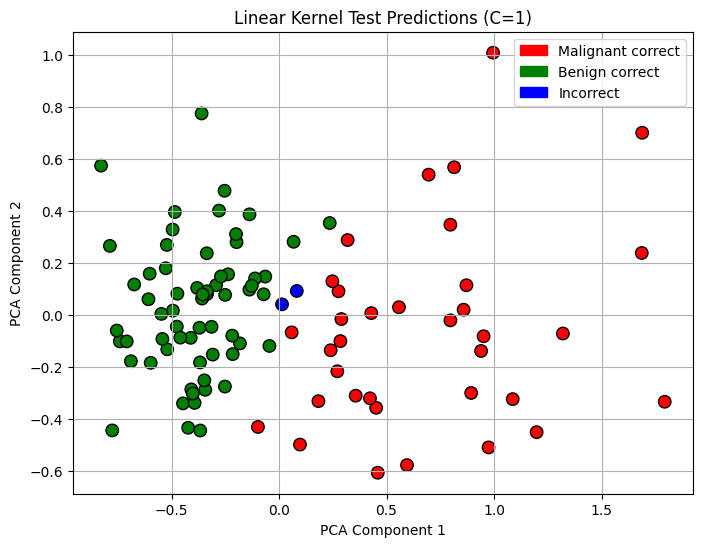

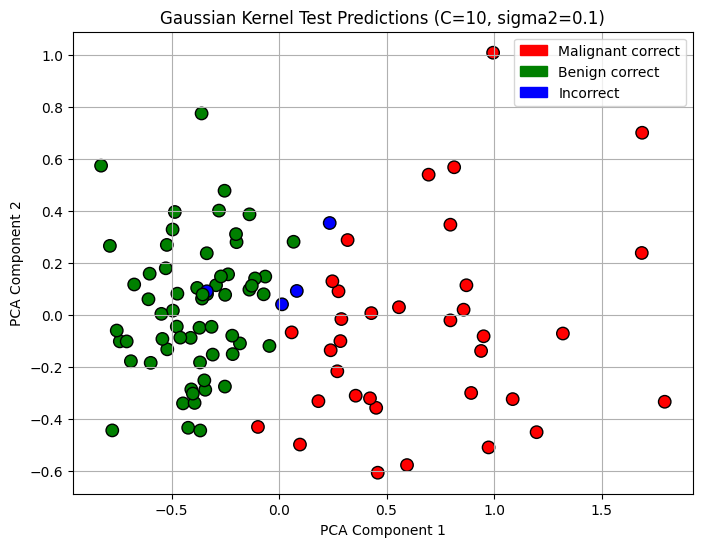

In [8]:
# Project test data to 2D using PCA
pca = PCA(n_components=2)
X_test_2D = pca.fit_transform(X_test)


# Linear Kernel Plot
colors_linear = []
for true, pred in zip(y_test, y_test_pred_linear):
    if true == pred and true == 1:
        colors_linear.append('red')      # Correct malignant
    elif true == pred and true == -1:
        colors_linear.append('green')    # Correct benign
    else:
        colors_linear.append('blue')     # Incorrect

plt.figure(figsize=(8,6))
plt.scatter(X_test_2D[:,0], X_test_2D[:,1], c=colors_linear, edgecolor='k', s=80)
plt.title(f"Linear Kernel Test Predictions (C={best_C_linear})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
red_patch = mpatches.Patch(color='red', label='Malignant correct')
green_patch = mpatches.Patch(color='green', label='Benign correct')
blue_patch = mpatches.Patch(color='blue', label='Incorrect')
plt.legend(handles=[red_patch, green_patch, blue_patch])
plt.show()


# Gaussian Kernel Plot
colors_gauss = []
for true, pred in zip(y_test, y_test_pred_gauss):
    if true == pred and true == 1:
        colors_gauss.append('red')      # Correct malignant
    elif true == pred and true == -1:
        colors_gauss.append('green')    # Correct benign
    else:
        colors_gauss.append('blue')     # Incorrect

plt.figure(figsize=(8,6))
plt.scatter(X_test_2D[:,0], X_test_2D[:,1], c=colors_gauss, edgecolor='k', s=80)
plt.title(f"Gaussian Kernel Test Predictions (C={best_C_gauss}, sigma2={best_sigma2})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
red_patch = mpatches.Patch(color='red', label='Malignant correct')
green_patch = mpatches.Patch(color='green', label='Benign correct')
blue_patch = mpatches.Patch(color='blue', label='Incorrect')
plt.legend(handles=[red_patch, green_patch, blue_patch])
plt.show()
